In [1]:
import gurobipy as gp
from gurobipy import GRB
from math import ceil


def F(state, q):
    """
    Degree-1 edge margin.

    state is ordered as:
        (Tw, T0, T1)

    where:
        Tw = seated winner's tally at time of seating
        T0 = Tc-Tl direct candidate-to-candidate margin component
        T1 = transfer-through-w margin component

    F > 0 supports the reported edge.
    Null is F <= 0.
    """
    Tw, T0, T1 = state

    if Tw <= 0:
        raise ValueError("Tw must be positive because it appears in a denominator.")

    return T0 + (1-q/Tw) * T1


def solve_bound_for_fixed_Tw(
    current_state,
    remaining_counts,
    type_vecs,
    q,
    M,
    Tw_final,
    integer=True,
    verbose=False,
    max_manipulation=None,
):
    """
    Solve the worst-case null-completion problem for a fixed final Tw.

    current_state:
        tuple (Tw_S, T0_S, T1_S)

    remaining_counts:
        dict reported_type -> number of remaining unsampled CVRs of that type

    type_vecs:
        dict type -> (Tw, T0, T1)

    q:
        quota

    M:
        allowed premature-election slack.
        Final Tw is allowed as low as q - M.

    Tw_final:
        enumerated final value of Tw.

    integer:
        If False, solve LP relaxation. This gives a conservative upper bound.

    Returns:
        None if infeasible, otherwise dict with objective and solution.
    """

    Tw_S, T0_S, T1_S = current_state

    if Tw_S <= 0:
        raise ValueError("Current Tw must be positive.")

    min_allowed_Tw = max(1, ceil(q - M))

    if Tw_final < min_allowed_Tw:
        return None

    reported_types = list(remaining_counts.keys())
    true_types = list(type_vecs.keys())

    pairs = [
        (r, t)
        for r in reported_types
        for t in true_types
        if remaining_counts[r] > 0
    ]

    # Correction vectors and current marginal effects.
    d = {}
    g = {}

    base_margin = F(current_state, q)

    valid_pairs = []

    for r, t in pairs:
        vr = type_vecs[r]
        vt = type_vecs[t]

        dTw = vt[0] - vr[0]
        dT0 = vt[1] - vr[1]
        dT1 = vt[2] - vr[2]

        one_step_Tw = Tw_S + dTw

        # If a single correction makes Tw nonpositive, the degree-1 formula is undefined.
        # Usually this should not happen in realistic edge-local states.
        if one_step_Tw <= 0:
            continue

        pair = (r, t)
        valid_pairs.append(pair)

        d[pair] = (dTw, dT0, dT1)

        next_state = (Tw_S + dTw, T0_S + dT0, T1_S + dT1)
        g[pair] = F(next_state, q) - base_margin

    m = gp.Model("degree1_understated_completion")
    if not verbose:
        m.Params.OutputFlag = 0

    vtype = GRB.INTEGER if integer else GRB.CONTINUOUS

    n = m.addVars(valid_pairs, lb=0, vtype=vtype, name="n")

    # Supply constraints: every remaining card reported as r gets assigned a true type t.
    for r in reported_types:
        feasible_true_types = [t for t in true_types if (r, t) in n]

        m.addConstr(
            gp.quicksum(n[r, t] for t in feasible_true_types)
            == remaining_counts[r],
            name=f"supply[{r}]",
        )

    if max_manipulation is not None:
        if max_manipulation < 0:
            raise ValueError("max_manipulation must be nonnegative.")

        m.addConstr(
            gp.quicksum(n[r, t] for r, t in valid_pairs if r != t)
            <= max_manipulation,
            name="max_manipulation",
        )

    Tw_f = Tw_S + gp.quicksum(n[p] * d[p][0] for p in valid_pairs)
    T0_f = T0_S + gp.quicksum(n[p] * d[p][1] for p in valid_pairs)
    T1_f = T1_S + gp.quicksum(n[p] * d[p][2] for p in valid_pairs)

    # Enumerated final seated-winner tally.
    m.addConstr(Tw_f == Tw_final, name="fix_Tw_final")

    # Premature-election slack:
    # instead of requiring Tw_f >= q, require Tw_f >= q - M.
    # Since Tw_f is fixed, this is mostly a guard.
    m.addConstr(Tw_f >= q - M, name="premature_election_slack")

    # Null constraint:
    #
    #   F(Tw_f, T0_f, T1_f) <= 0
    #
    # Since Tw_f is fixed to Tw_final:
    #
    #   T0_f + (1 - q / Tw_final) T1_f <= 0
    #
    # Multiplying by positive Tw_final:
    #
    #   Tw_final * T0_f + (Tw_final - q) * T1_f <= 0
    #
    m.addConstr(
        Tw_final * T0_f + (Tw_final - q) * T1_f <= 0,
        name="null_margin",
    )

    # Maximize numerator of the worst-case current expected marginal effect.
    m.setObjective(
        gp.quicksum(n[p] * g[p] for p in valid_pairs),
        GRB.MAXIMIZE,
    )

    m.optimize()

    if m.Status == GRB.OPTIMAL:
        return {
            "objective": m.ObjVal,
            "Tw_final": Tw_final,
            "solution": {p: n[p].X for p in valid_pairs if abs(n[p].X) > 1e-8},
        }

    m.optimize()

    if m.Status == GRB.INF_OR_UNBD:
        m.Params.DualReductions = 0
        m.optimize()

    if m.Status == GRB.OPTIMAL:
        return {
            "objective": m.ObjVal,
            "Tw_final": Tw_final,
            "solution": {p: n[p].X for p in valid_pairs if abs(n[p].X) > 1e-8},
        }

    if m.Status in (GRB.INFEASIBLE, GRB.INF_OR_UNBD):
        return None

    if m.Status == GRB.TIME_LIMIT:
        raise RuntimeError("Gurobi hit the time limit")

    print(f"Optimization failed with parameters:\n current_state={current_state}\nremaining_counts={remaining_counts}\ntype_vecs={type_vecs}\nq={q}\nM={M}\nTw_final={Tw_final}\ninteger={integer}")
    
    raise RuntimeError(f"Gurobi ended with status {m.Status}")



def solve_degree1_mu_bound(
    current_state,
    remaining_counts,
    type_vecs,
    q,
    M,
    N_total,
    integer=True,
    max_manipulation=None,
):
    """
    Compute a conservative upper bound on

        E_null[Delta_j | history]

    by maximizing the current marginal-effect numerator over all null completions.

    State order everywhere:
        (Tw, T0, T1)
    """

    R = sum(remaining_counts.values())

    if R <= 0:
        raise ValueError("No remaining ballots to sample.")

    best = None

    min_allowed_Tw = max(1, ceil(q - M))
    max_allowed_Tw = N_total

    for Tw_final in range(min_allowed_Tw, max_allowed_Tw + 1):
        out = solve_bound_for_fixed_Tw(
            current_state=current_state,
            remaining_counts=remaining_counts,
            type_vecs=type_vecs,
            q=q,
            M=M,
            max_manipulation=max_manipulation,
            Tw_final=Tw_final,
            integer=integer,
        )

        if out is None:
            continue

        if best is None or out["objective"] > best["objective"]:
            best = out

    if best is None:
        # No null completion exists given the current history.
        return {
            "null_feasible": False,
            "mu": None,
            "best": None,
        }

    return {
        "null_feasible": True,
        "mu": best["objective"] / R,
        "best": best,
    }

In [4]:
solve_degree1_mu_bound(
    current_state=(150, -5, 60),
    remaining_counts = {
        "C": 70,
        "L": 75,
        "Wc": 60,
        "Wl": 0,
        "Wo": 90,
        "O": 2,
    },
    type_vecs = {
        "C":  (0, 1, 0),
        "L":  (0, -1, 0),
        "Wc": (1, 0, 1),
        "Wl": (1, 0, -1),
        "Wo": (1, 0, 0),
        "O":  (0, 0, 0),
    },
    q=100,
    M=0,
    N_total=297,
    integer=False,
    max_manipulation=30,
)

{'null_feasible': True,
 'mu': -0.035416713120907876,
 'best': {'objective': -10.518763796909639,
  'Tw_final': 180,
  'solution': {('C', 'C'): 50.83333333333333,
   ('C', 'Wl'): 19.166666666666668,
   ('L', 'L'): 64.16666666666666,
   ('L', 'Wl'): 10.83333333333334,
   ('Wc', 'Wc'): 60.0,
   ('Wo', 'Wo'): 90.0,
   ('O', 'O'): 2.0}}}

In [4]:
solve_degree1_mu_bound(
    current_state=(100, -5, 0),
    remaining_counts = {
        "C": 75,
        "L": 70,
        "Wc": 0,
        "Wl": 0,
        "Wo": 100,
        "O": 52,
    },
    type_vecs = {
        "C":  (0, 1, 0),
        "L":  (0, -1, 0),
        "Wc": (1, 0, 1),
        "Wl": (1, 0, -1),
        "Wo": (1, 0, 0),
        "O":  (0, 0, 0),
    },
    q=100,
    M=0,
    N_total=297,
    integer=False,
    max_manipulation=50,
)

{'null_feasible': True,
 'mu': 0.07128490626840461,
 'best': {'objective': 21.17161716171617,
  'Tw_final': 150,
  'solution': {('C', 'C'): 60.833333333333336,
   ('C', 'Wl'): 14.166666666666663,
   ('L', 'L'): 34.16666666666667,
   ('L', 'Wl'): 35.83333333333333,
   ('Wo', 'Wo'): 100.0,
   ('O', 'O'): 52.0}}}

In [3]:
import random

remaining_counts = {
        "C": 70,
        "L": 75,
        "Wc": 0,
        "Wl": 0,
        "Wo": 100,
        "O": 52,
    }

mu_values = []
for i in range(297):
    # pick a random integer between 1 and 6 with probability proportional to the number of remaining cards of that type
    print(f"Iteration {i+1}")
    current_optimal = solve_degree1_mu_bound(
        current_state=(150, -5, 60),
        remaining_counts = remaining_counts,
        type_vecs = {
            "C":  (0, 1, 0),
            "L":  (0, -1, 0),
            "Wc": (1, 0, 1),
            "Wl": (1, 0, -1),
            "Wo": (1, 0, 0),
            "O":  (0, 0, 0),
        },
        q=100,
        M=0,
        N_total=297,
        integer=False,
    )
    mu_values.append(current_optimal["mu"])
    r = random.choices(population=list(remaining_counts.keys()), weights=list(remaining_counts.values()))[0]
    remaining_counts[r] -= 1

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15


KeyboardInterrupt: 

In [30]:
mu5 =mu_values

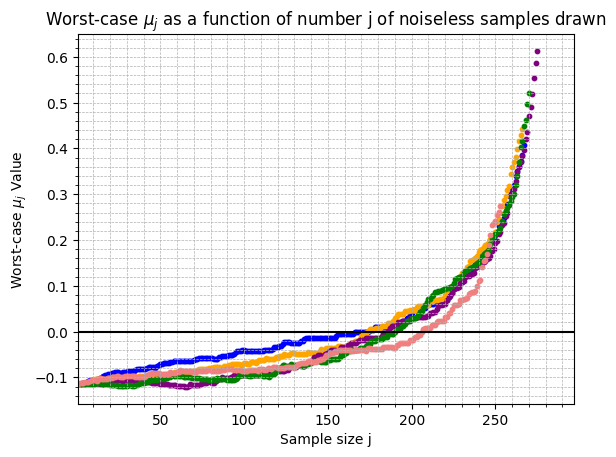

In [34]:
# scatter plot of mu_values against iteration number
import matplotlib.pyplot as plt

# flip the sign of all mu_values so that they are negative
mu1 = [-x for x in mu1]
mu2 = [-x for x in mu2]
mu3 = [-x for x in mu3]
mu4 = [-x for x in mu4]
mu5 = [-x for x in mu5]

plt.scatter(range(1, len(mu1) + 1), mu1, color='blue', s=10)
# also plot mu2 in orange
plt.scatter(range(1, len(mu2) + 1), mu2, color='orange', s=10)
# also plot mu3 in purple
plt.scatter(range(1, len(mu3) + 1), mu3, color='purple', s=10)
# also plot mu4 in green
plt.scatter(range(1, len(mu4) + 1), mu4, color='green', s=10)
# also plot mu5 in lightcoral
plt.scatter(range(1, len(mu5) + 1), mu5, color='lightcoral', s=10) 
# change the range of x axis to be 1 to 297
plt.xlim(1, 297)
# make it look like graph paper
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# make it finer
plt.minorticks_on()
# add solid grid line at y = 0
plt.axhline(0, color='black', linestyle='-')

plt.xlabel("Sample size j")
plt.ylabel(r"Worst-case $\mu_j$ Value")
plt.title(r"Worst-case $\mu_j$ as a function of number j of noiseless samples drawn")
plt.show()

In [4]:
import random

universe = [(0, -2, 0)]*69 + [(1, 1, -1)]*52 + [(1, -1, 1)]*6 + [(1, 1, 1)]*18 + [(0, 0, 2)]*60 + [(0, 0, 1)]*90 + [(1, 0, 1)]*1+ [(1, 0, 0)]*1

samples = dict()
for sample_j in range(1,101):
    current_tuple = (150, 5, -60)
    random.shuffle(universe)
    F_starting = F(current_tuple, 100)
    margin_values = [F_starting]
    for delta in universe:
        current_tuple = (current_tuple[0] + delta[0], current_tuple[1] + delta[1], current_tuple[2] + delta[2])
        margin_values.append(F(current_tuple, 100))
    samples[sample_j] = margin_values

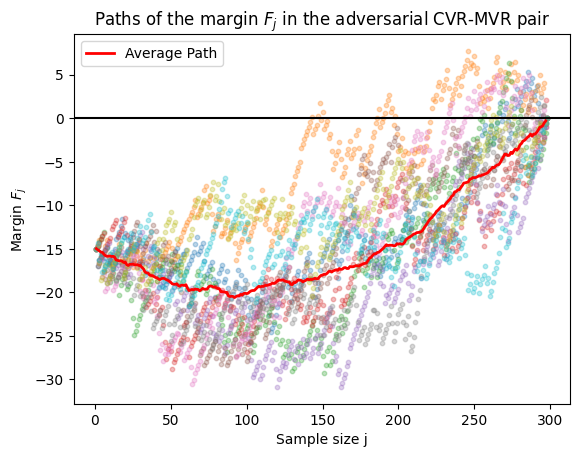

In [5]:
import matplotlib.pyplot as plt

# plot all 10 margin value sequences on the same graph, with 40% opacity

for samplie_j in range(31, 41):
    margin_values = samples[samplie_j]
    plt.scatter(range(1, len(margin_values) + 1), margin_values, alpha=0.3, s=10)

average_path = [sum(samples[sample_j][i] for sample_j in range(1,101)) / 100 for i in range(297)]
plt.plot(range(1, len(average_path) + 1), average_path, color='red', linestyle='-', linewidth=2, label='Average Path')
plt.legend()
plt.axhline(0, color='black', linestyle='-')
plt.xlabel("Sample size j")
plt.ylabel(r"Margin $F_j$")
plt.title(r"Paths of the margin $F_j$ in the adversarial CVR-MVR pair")
plt.show()

0.3973509933774899


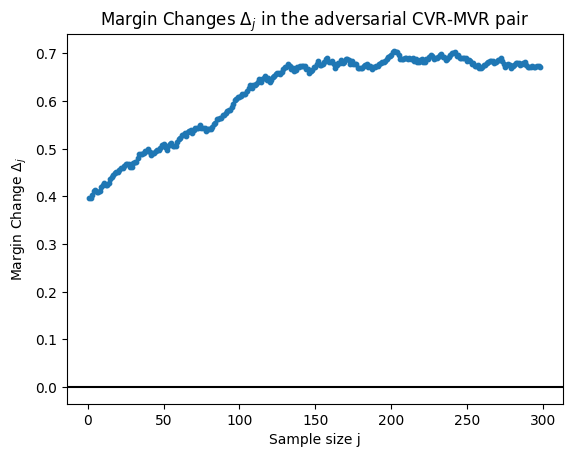

In [6]:
F((151, -6, 61), 100)-F((150, -5, 60), 100)

current_tuple = (150, 5, -60)

def shift_tup(tup):
    return (tup[0]+1, tup[1]+1, tup[2]-1)

universe = [(0, -2, 0)]*69 + [(1, 1, -1)]*52 + [(1, -1, 1)]*6 + [(1, 1, 1)]*18 + [(0, 0, 2)]*60 + [(0, 0, 1)]*90 + [(1, 0, 1)]*1+ [(1, 0, 0)]*1
random.shuffle(universe)
starting_delta = F(shift_tup(current_tuple),100)-F(current_tuple, 100)
print(starting_delta)
delta_values = [starting_delta]
for x in universe:
    current_tuple = (current_tuple[0] + x[0], current_tuple[1] + x[1], current_tuple[2] + x[2])
    delta = F(shift_tup(current_tuple), 100)-F(current_tuple, 100)
    delta_values.append(delta)

#scatter plot of delta_values against iteration number
import matplotlib.pyplot as plt

plt.scatter(range(1, len(delta_values) + 1), delta_values, s=10)
plt.axhline(0, color='black', linestyle='-')
plt.xlabel("Sample size j")
plt.ylabel(r"Margin Change $\Delta_j$")
plt.title(r"Margin Changes $\Delta_j$ in the adversarial CVR-MVR pair")
plt.show()